<a href="https://colab.research.google.com/github/mankmana/DataScience-Assignments/blob/main/Assignment1_PArt1_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

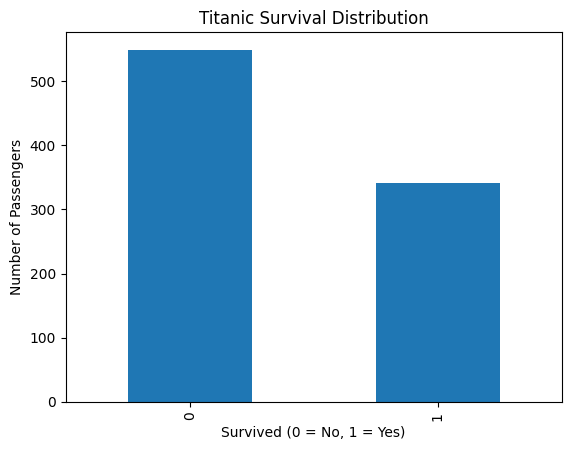

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


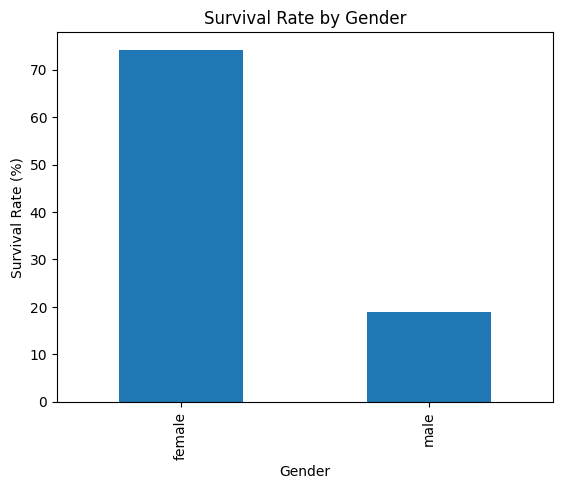

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


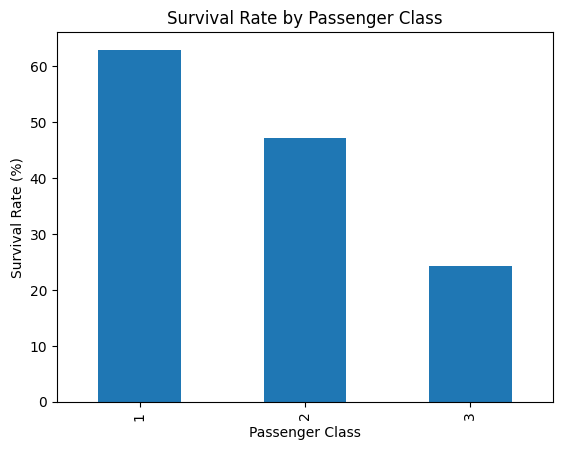

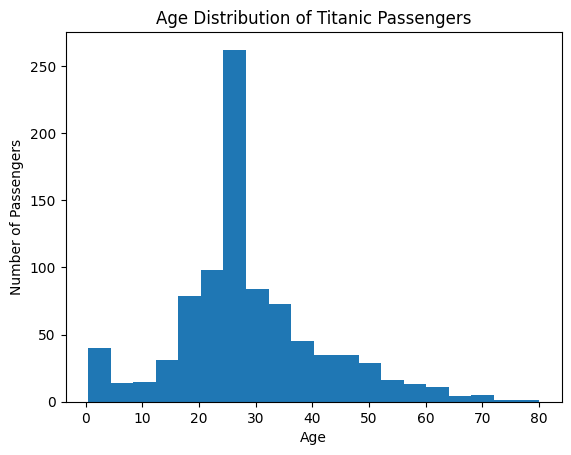

Survived
0    30.028233
1    28.291433
Name: Age, dtype: float64


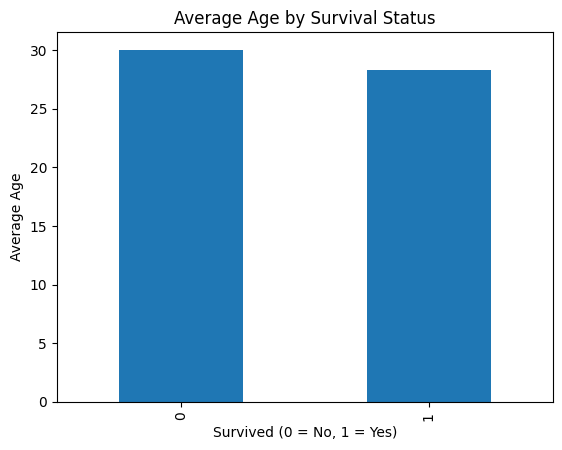

AgeGroup
Child     57.971014
Teen      47.727273
Adult     36.436170
Senior    26.923077
Name: Survived, dtype: float64


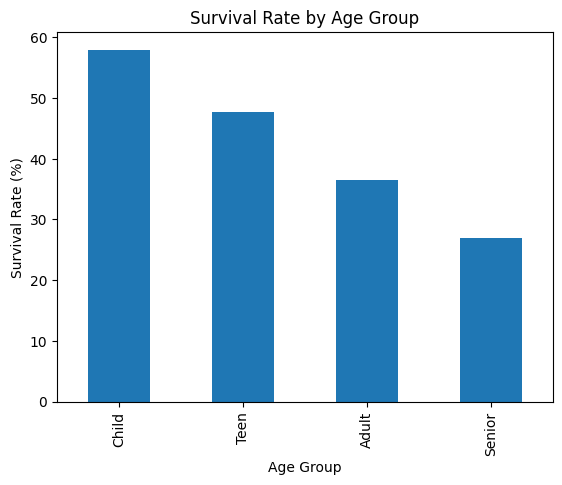

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64


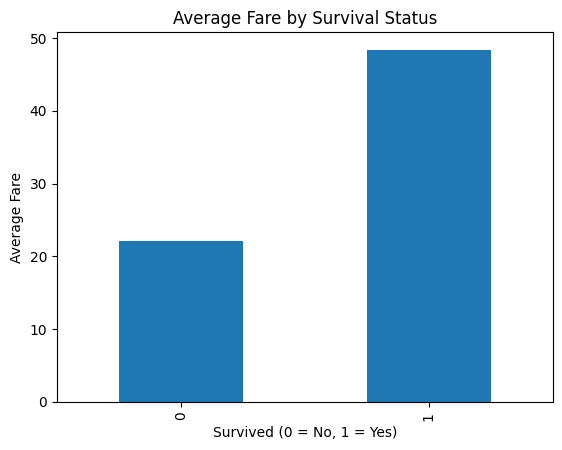

Training rows: 712
Testing rows: 179
Model training complete
[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0]
Model Accuracy: 81.00558659217877 %
[[90 15]
 [19 55]]


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from sklearn.metrics import confusion_matrix

train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

#train_df.info()
#train_df.isnull().sum()
# Fill missing Age values with the median age
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())

# Fill missing Embarked values with the most common value
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

# Drop Cabin because too many values are missing
train_df = train_df.drop(columns=['Cabin'])

# Plot the number of passengers who survived and did not survive
train_df['Survived'].value_counts().plot(kind='bar')

plt.title('Titanic Survival Distribution')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')

plt.show()


# Calculate survival rate by gender and convert it to percentage
survival_by_sex = train_df.groupby('Sex')['Survived'].mean() * 100

print(survival_by_sex)

# Plot survival percentage for male and female passengers
survival_by_sex.plot(kind='bar')

plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate (%)')

plt.show()

# Calculate survival rate by passenger class and convert it to percentage
survival_by_class = train_df.groupby('Pclass')['Survived'].mean() * 100

print(survival_by_class)

# Plot survival percentage for 1st, 2nd, and 3rd class passengers
survival_by_class.plot(kind='bar')

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')

plt.show()

# Show how passenger ages are distributed
train_df['Age'].plot(kind='hist', bins=20)

plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()


# Compare the average age of passengers who survived and did not survive
average_age_by_survival = train_df.groupby('Survived')['Age'].mean()

print(average_age_by_survival)

average_age_by_survival.plot(kind='bar')

plt.title('Average Age by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Average Age')

plt.show()

# Create age groups
train_df['AgeGroup'] = pd.cut(
    train_df['Age'],
    bins=[0, 12, 17, 59, 100],
    labels=['Child', 'Teen', 'Adult', 'Senior']
)

# Calculate survival rate for each age group
survival_by_age_group = train_df.groupby('AgeGroup', observed=False)['Survived'].mean() * 100

print(survival_by_age_group)

# Plot the survival rate
survival_by_age_group.plot(kind='bar')

plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate (%)')

plt.show()

# Calculate average fare for survivors and non-survivors
average_fare_by_survival = train_df.groupby('Survived')['Fare'].mean()

print(average_fare_by_survival)

# Plot the average fare
average_fare_by_survival.plot(kind='bar')

plt.title('Average Fare by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Average Fare')

plt.show()

# Select the input features we want the model to use
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

# X contains the input data
X = train_df[features]

# y contains the answer we want to predict
y = train_df['Survived']

# Convert text categories into numerical columns
X = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)

# View the prepared data
X.head()

# Select the input features we want the model to use
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

# X contains the input data
X = train_df[features]

# y contains the answer we want to predict
y = train_df['Survived']

# Convert text categories into numerical columns
X = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)

# View the prepared data
X.head()



# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))



# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model using the training data
model.fit(X_train, y_train)

print("Model training complete")

# Use the trained model to predict survival for the test set
y_pred = model.predict(X_test)

print(y_pred[:20])



accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy * 100, "%")


cm = confusion_matrix(y_test, y_pred)

print(cm)